Starting Data:
Original dataset files (Dataset1.zip, Dataset2.rar, Dataset3.zip,Dataset4.zip, Dataset5.zip)
stored in: /content/drive/MyDrive

1. Data Extraction:
- Extracted all .zip and .rar files into:
 /content/drive/MyDrive/extracted

2. Data Fusion (Merging Datasets):
- Traversed all extracted folders (handled both direct and nested structures)
- Collected all images and merged them class-wise into:
 /content/drive/MyDrive/Final data

3. Class Label Standardization:
- Converted class names to lowercase
- Unified naming format across all datasets

4. Duplicate Handling:
- If duplicate filenames were found, renamed them with incremental suffixes to prevent overwriting

5. Data Cleaning:
- Retained only valid image formats (.jpg, .jpeg, .png, .webp)
- Ignored non-image files and irrelevant data

6. Dataset Verification:
- Computed class-wise image counts
- Visualized distribution using:
- Bar plots (class distribution)
- Histogram (dataset balance)

7. Weak Class Removal (Balancing Step):
- Removed classes with very low samples (MIN_IMAGES = 30)
- Example: removed 'sutar_feni' (15 images)
- Final dataset contains 89 classes

8. Dataset Splitting:
- Randomly split data into:
  - Train (70%)
  - Validation (15%)
  - Test (15%)
- Saved in:
  - /content/drive/MyDrive/split_data/train
  - /content/drive/MyDrive/split_data/val
  - /content/drive/MyDrive/split_data/test

9. Data Augmentation (Training Only):
- Resize to 224x224
- Random horizontal flip
- Random rotation (±20 degrees)
- Color jitter (brightness & contrast)
- Normalization using ImageNet mean & std

10. Data Preparation:
- Created datasets using ImageFolder
- Loaded data using DataLoader (batch size = 32)

11. Class Imbalance Handling:
- Computed class weights based on frequency
- Applied weights in CrossEntropyLoss



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get install unrar -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import os
import shutil
import zipfile
import matplotlib.pyplot as plt
import random

In [ ]:
base_path = "/content/drive/MyDrive"
extract_path = os.path.join(base_path, "extracted")
final_path = os.path.join(base_path, "Final data")

In [ ]:
for file in os.listdir(base_path):
    file_path = os.path.join(base_path, file)

    # ZIP extraction
    if file.endswith(".zip"):
        print("Extracting ZIP:", file)
        try:
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(extract_path)
        except Exception as e:
            print("ZIP Error:", file, e)

    # RAR extraction
    elif file.endswith(".rar"):
        print("Extracting RAR:", file)
        os.system(f'unrar x "{file_path}" "{extract_path}/"')

In [ ]:
print("Extracted content:")
print(os.listdir(extract_path))

Extracted content:
['Dataset1.zip', 'Dataset5.zip', 'Dataset2.rar', 'Dataset3.zip', 'Dataset4.zip']


In [ ]:
image_ext = (".jpg", ".jpeg", ".png", ".webp")

def copy_to_class(src_folder, class_name):
    class_name = class_name.strip().lower()
    target_class = os.path.join(final_path, class_name)
    os.makedirs(target_class, exist_ok=True)

    for file in os.listdir(src_folder):
        if file.lower().endswith(image_ext):

            src = os.path.join(src_folder, file)
            dst = os.path.join(target_class, file)

            if os.path.exists(dst):
                base, ext = os.path.splitext(file)
                i = 1
                while os.path.exists(os.path.join(target_class, f"{base}_{i}{ext}")):
                    i += 1
                dst = os.path.join(target_class, f"{base}_{i}{ext}")

            shutil.copy2(src, dst)


def process_folder(folder_path):
    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)

        if not os.path.isdir(item_path):
            continue

        inner_items = os.listdir(item_path)

        # Case 1: Direct class folder (contains images)
        if any(f.lower().endswith(image_ext) for f in inner_items):
            copy_to_class(item_path, item)

        # Case 2: Nested structure
        else:
            for sub in inner_items:
                sub_path = os.path.join(item_path, sub)

                if os.path.isdir(sub_path):
                    if any(f.lower().endswith(image_ext) for f in os.listdir(sub_path)):
                        copy_to_class(sub_path, sub)

for folder in os.listdir(extract_path):
    path = os.path.join(extract_path, folder)

    if os.path.isdir(path):
        print("Processing:", folder)
        process_folder(path)

print("\n CLASS-WISE MERGE DONE")


 CLASS-WISE MERGE DONE


In [ ]:
for cls in os.listdir(final_path):
    cls_path = os.path.join(final_path, cls)
    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))

In [ ]:
final_path = "/content/drive/MyDrive/Final data"

num_classes = 0
total_images = 0
class_counts = []

for cls in os.listdir(final_path):
    cls_path = os.path.join(final_path, cls)

    if os.path.isdir(cls_path):
        num_classes += 1

        num_images = len(os.listdir(cls_path))
        total_images += num_images

        class_counts.append((cls, num_images))

# sort classes by image count
class_counts.sort(key=lambda x: x[1], reverse=True)

print("DATASET SUMMARY\n")

print("Total Classes:", num_classes)
print("Total Images:", total_images)

print("\n Top 5 Classes:")
for cls, count in class_counts[:5]:
    print(cls, ":", count)

print("\n Bottom 5 Classes:")
for cls, count in class_counts[-5:]:
    print(cls, ":", count)

print("\n Min images in a class:", min([c[1] for c in class_counts]))
print(" Max images in a class:", max([c[1] for c in class_counts]))
print(" Average images per class:", total_images // num_classes)

DATASET SUMMARY

Total Classes: 0
Total Images: 0

 Top 5 Classes:

 Bottom 5 Classes:


ValueError: min() iterable argument is empty

**EDA**

In [ ]:
final_path = "/content/drive/MyDrive/Final data"

classes = []
counts = []

for cls in os.listdir(final_path):
    cls_path = os.path.join(final_path, cls)
    if os.path.isdir(cls_path):
        classes.append(cls)
        counts.append(len(os.listdir(cls_path)))

# sort descending
classes_counts = sorted(zip(classes, counts), key=lambda x: x[1], reverse=True)
classes, counts = zip(*classes_counts)

plt.figure(figsize=(14,6))
plt.bar(classes, counts)

plt.xticks(rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Dataset")

plt.tight_layout()
plt.show()

In [ ]:
top_n = 10

plt.figure(figsize=(10,5))
plt.bar(classes[:top_n], counts[:top_n])

plt.xticks(rotation=45)
plt.xlabel("Top Classes")
plt.ylabel("Number of Images")
plt.title("Top 10 Classes by Image Count")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(counts, bins=10)

plt.xlabel("Images per class")
plt.ylabel("Number of classes")
plt.title("Dataset Distribution Histogram")

plt.tight_layout()
plt.show()

In [ ]:
bottom_n = 15

plt.figure(figsize=(12,6))
plt.barh(classes[-bottom_n:], counts[-bottom_n:])

plt.xlabel("Number of Images")
plt.ylabel("Classes")
plt.title("Bottom 15 Classes")

plt.tight_layout()
plt.show()

**Data Augmentation**

In [ ]:
base_dir = "/content/drive/MyDrive/Final data"

class_counts = {}

for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)

    if os.path.isdir(cls_path):
        num_images = len(os.listdir(cls_path))
        class_counts[cls] = num_images

# Print all classes with counts
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


bisi_bele_bath: 73
chaat: 80
dosa: 91
medu_vada: 95
noodles: 72
paniyaram: 58
puri: 74
suji_halwa: 68
tandoori_chicken: 57
upma: 61
ven_pongal: 60
adhirasam: 50
aloo_gobi: 250
aloo_matar: 50
aloo_methi: 50
aloo_shimla_mirch: 50
aloo_tikki: 50
anarsa: 50
ariselu: 50
bandar_laddu: 50
basundi: 50
bhatura: 50
bhindi_masala: 450
biryani: 450
boondi: 50
butter_chicken: 50
chak_hao_kheer: 50
cham_cham: 50
chana_masala: 50
chapati: 663
chhena_kheeri: 50
chicken_razala: 50
chicken_tikka: 50
chicken_tikka_masala: 50
chikki: 50
daal_baati_churma: 50
daal_puri: 50
dal_makhani: 771
dal_tadka: 50
dharwad_pedha: 50
doodhpak: 50
double_ka_meetha: 50
dum_aloo: 250
gajar_ka_halwa: 50
gavvalu: 50
ghevar: 250
gulab_jamun: 340
imarti: 50
jalebi: 1350
kachori: 50
kadai_paneer: 462
kadhi_pakoda: 50
kajjikaya: 50
kakinada_khaja: 50
kalakand: 50
karela_bharta: 50
kofta: 717
kuzhi_paniyaram: 50
lassi: 250
ledikeni: 50
litti_chokha: 50
lyangcha: 50
maach_jhol: 50
makki_di_roti_sarson_da_saag: 50
malapua: 50
misi

In [ ]:
MIN_IMAGES = 30

for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)

    if os.path.isdir(cls_path):
        num_images = len(os.listdir(cls_path))

        if num_images < MIN_IMAGES:
            print(f"Removing {cls} ({num_images} images)")
            shutil.rmtree(cls_path)

print("Weak classes removed")

Removing sutar_feni (15 images)
✅ Weak classes removed


In [ ]:
class_counts = {}

for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)

    if os.path.isdir(cls_path):
        num_images = len(os.listdir(cls_path))
        class_counts[cls] = num_images

counts = list(class_counts.values())

print("DATASET SUMMARY")
print("Total Classes:", len(class_counts))
print("Min images in a class:", min(counts))
print("Max images in a class:", max(counts))
print("Average images per class:", sum(counts)//len(counts))

📊 DATASET SUMMARY
Total Classes: 89
Min images in a class: 50
Max images in a class: 1350
Average images per class: 132


In [ ]:
print("\n Classes (Lowest → Highest):\n")

for cls, count in sorted(class_counts.items(), key=lambda x: x[1]):
    print(f"{cls}: {count}")


🔽 Classes (Lowest → Highest):

adhirasam: 50
aloo_matar: 50
aloo_methi: 50
aloo_shimla_mirch: 50
aloo_tikki: 50
anarsa: 50
ariselu: 50
bandar_laddu: 50
basundi: 50
bhatura: 50
boondi: 50
butter_chicken: 50
chak_hao_kheer: 50
cham_cham: 50
chana_masala: 50
chhena_kheeri: 50
chicken_razala: 50
chicken_tikka: 50
chicken_tikka_masala: 50
chikki: 50
daal_baati_churma: 50
daal_puri: 50
dal_tadka: 50
dharwad_pedha: 50
doodhpak: 50
double_ka_meetha: 50
gajar_ka_halwa: 50
gavvalu: 50
imarti: 50
kachori: 50
kadhi_pakoda: 50
kajjikaya: 50
kakinada_khaja: 50
kalakand: 50
karela_bharta: 50
kuzhi_paniyaram: 50
ledikeni: 50
litti_chokha: 50
lyangcha: 50
maach_jhol: 50
makki_di_roti_sarson_da_saag: 50
malapua: 50
misi_roti: 50
misti_doi: 50
mysore_pak: 50
navrattan_korma: 50
paneer_butter_masala: 50
phirni: 50
pithe: 50
poornalu: 50
pootharekulu: 50
qubani_ka_meetha: 50
rabri: 50
rasgulla: 50
sandesh: 50
shankarpali: 50
sheer_korma: 50
sheera: 50
shrikhand: 50
sohan_halwa: 50
sohan_papdi: 50
tandoori

In [ ]:
small_classes = [cls for cls, count in class_counts.items() if count < 30]

print("\n Classes with <30 images:", small_classes)

NameError: name 'class_counts' is not defined

**Spliting the dataset**

In [ ]:
base_dir = "/content/drive/MyDrive/Final data"
output_dir = "/content/drive/MyDrive/split_data"

train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
test_dir = os.path.join(output_dir, "test")

# create folders
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)

    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    n = len(images)
    train_split = int(0.7 * n)
    val_split = int(0.85 * n)

    train_imgs = images[:train_split]
    val_imgs = images[train_split:val_split]
    test_imgs = images[val_split:]

    # create class folders
    for folder in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

    def copy_images(img_list, dest_folder):
        for img in img_list:
            src = os.path.join(cls_path, img)
            dst = os.path.join(dest_folder, cls, img)
            shutil.copy2(src, dst)

    copy_images(train_imgs, train_dir)
    copy_images(val_imgs, val_dir)
    copy_images(test_imgs, test_dir)

print("Dataset split completed")

✅ Dataset split completed


In [ ]:
for split in ["train", "val", "test"]:
    path = f"/content/drive/MyDrive/split_data/{split}"
    print(split, "classes:", len(os.listdir(path)))

train classes: 89
val classes: 89
test classes: 89


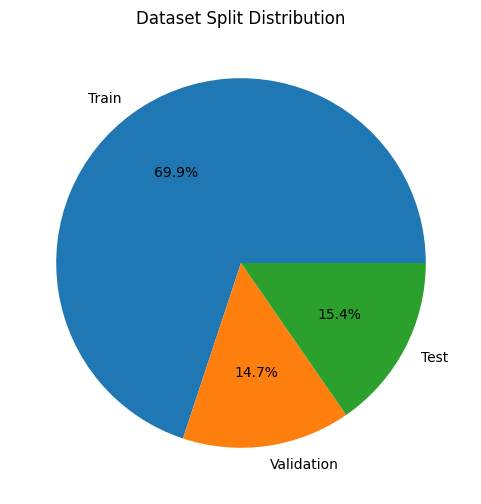

In [ ]:
import matplotlib.pyplot as plt

train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)

plt.figure(figsize=(6,6))
plt.pie([train_size, val_size, test_size],
        labels=["Train", "Validation", "Test"],
        autopct='%1.1f%%')

plt.title("Dataset Split Distribution")
plt.show()

In [ ]:
from torchvision import transforms

IMG_SIZE = 224

# TRAIN (augmentation applied)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# VAL & TEST (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
from torchvision.datasets import ImageFolder

train_dir = "/content/drive/MyDrive/split_data/train"
val_dir = "/content/drive/MyDrive/split_data/val"
test_dir = "/content/drive/MyDrive/split_data/test"

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=val_test_transform)
test_dataset = ImageFolder(test_dir, transform=val_test_transform)

print("Classes:", len(train_dataset.classes))

Classes: 89


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready")

✅ DataLoaders ready
